# Overview

Welcome to the 2025 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

Your Goal: The goal of this competition is to predict a song's beats-per-minute.

Submissions are evaluated using the Root Mean Squared Error between the predicted and the observed target.
Submission File

For each id in the test set, you must predict a continuous-valued BeatsPerMinute. The file should contain a header and have the following format:

ID,BeatsPerMinute
524164,119.5
524165,127.42
524166,111.11
etc.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# ONLY FOR KAGGLE
sample_submission_path = "/kaggle/input/playground-series-s5e9/sample_submission.csv"
train_path = "/kaggle/input/playground-series-s5e9/train.csv"
test_path = "/kaggle/input/playground-series-s5e9/test.csv"

# Dataset exploration

In [22]:
# Imports and settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

cur_dir = os.getcwd()

DATA_DIR = "/data"
train_dataset = "train.csv"
test_dataset = "test.csv"

train_path = cur_dir + os.path.join(DATA_DIR, train_dataset)
test_path = cur_dir + os.path.join(DATA_DIR, test_dataset)


print("Current directory: ", cur_dir)
print("Data directory: ", DATA_DIR)
print("Train dataset: ", train_dataset)
print("Test dataset: ", test_dataset)

print("Train path: ", train_path)
print("Test path: ", test_path)
print("Train path exists: ", os.path.exists(train_path))
print("Test path exists: ", os.path.exists(test_path))



Current directory:  /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction
Data directory:  /data
Train dataset:  train.csv
Test dataset:  test.csv
Train path:  /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/data/train.csv
Test path:  /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/data/test.csv
Train path exists:  True
Test path exists:  True


In [24]:
# Load data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Shapes:")
print({"train": train.shape, "test": test.shape})

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nData types (train):")
print(train.dtypes)

print("\nData types (test):")
print(test.dtypes)


Shapes:
{'train': (524164, 11), 'test': (174722, 10)}

Train columns:
['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy', 'BeatsPerMinute']

Test columns:
['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy']

Data types (train):
id                             int64
RhythmScore                  float64
AudioLoudness                float64
VocalContent                 float64
AcousticQuality              float64
InstrumentalScore            float64
LivePerformanceLikelihood    float64
MoodScore                    float64
TrackDurationMs              float64
Energy                       float64
BeatsPerMinute               float64
dtype: object

Data types (test):
id                             int64
RhythmScore                  float64
AudioLoudness                

In [25]:
# Quick peeks
from IPython.display import display

print("Train head:")
display(train.head())

print("\nTest head:")
display(test.head())

print("\nTrain describe (numeric):")
display(train.describe())

print("\nMissing values (train):")
display(train.isna().sum().sort_values(ascending=False))

print("\nMissing values (test):")
display(test.isna().sum().sort_values(ascending=False))


Train head:


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511



Test head:


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067



Train describe (numeric):


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257587,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000



Missing values (train):


id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64


Missing values (test):


id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
dtype: int64

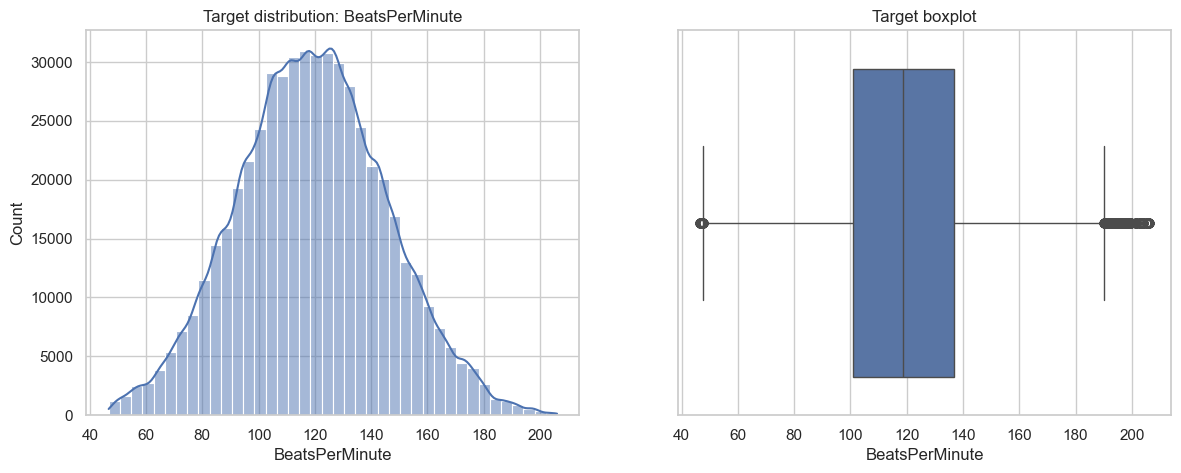

Top correlations with target:


MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
id                          -0.000355
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64

In [40]:
# Target distribution and correlations (if target exists)
TARGET = "BeatsPerMinute"

if TARGET in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(train[TARGET].dropna(), kde=True, ax=axes[0], bins=40)
    axes[0].set_title("Target distribution: BeatsPerMinute")
    sns.boxplot(x=train[TARGET], ax=axes[1])
    axes[1].set_title("Target boxplot")
    plt.show()

    numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    corr = train[numeric_cols].corr(numeric_only=True)
    if TARGET in corr.columns:
        top_corr = (
            corr[TARGET]
            .drop(labels=[TARGET])
            .sort_values(ascending=False)
            .head(15)
        )
        print("Top correlations with target:")
        display(top_corr)
else:
    print(f"Target column '{TARGET}' not found in train.")


Numeric features considered:
['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy']


,feature,train_mean,test_mean,train_std,test_std,train_min,test_min,train_max,test_max
0,RhythmScore,0.632843,0.632591,0.156899,0.157229,0.076900,0.140859,0.975000,0.975000
1,AudioLoudness,-8.379014,-8.377495,4.616221,4.622288,-27.509725,-27.442731,-1.357000,-1.357000
2,VocalContent,0.074443,0.074475,0.049939,0.050024,0.023500,0.023500,0.256401,0.258857
3,AcousticQuality,0.262913,0.262903,0.223120,0.222899,0.000005,0.000005,0.995000,0.995000
4,InstrumentalScore,0.117690,0.117407,0.131845,0.131628,0.000001,0.000001,0.869258,0.680914
5,LivePerformanceLikelihood,0.178398,0.178317,0.118186,0.118165,0.024300,0.024300,0.599924,0.599544
6,MoodScore,0.555843,0.555861,0.225480,0.226218,0.025600,0.025600,0.978000,0.978000
7,TrackDurationMs,241903.692949,241753.736419,59326.601501,59103.896616,63973.000000,63973.000000,464723.228100,449288.808400
8,Energy,0.500923,0.500545,0.289952,0.290550,0.000067,0.000067,1.000000,0.999867


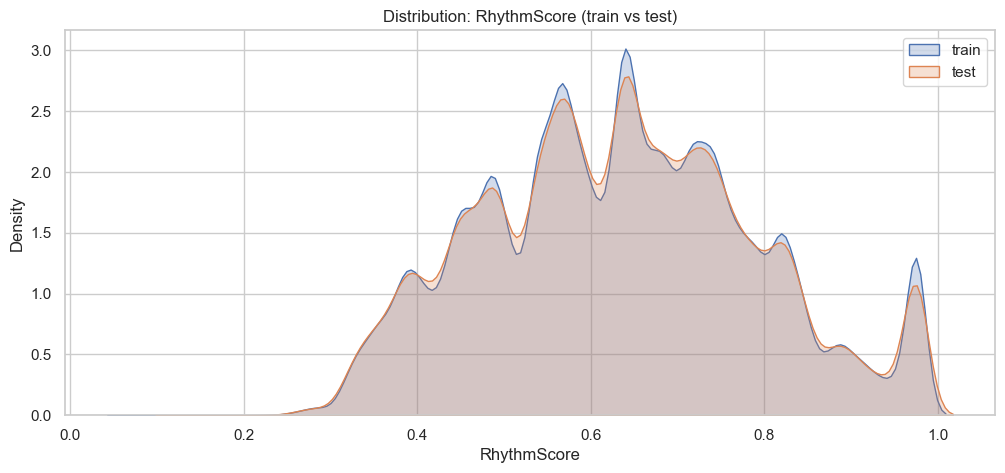

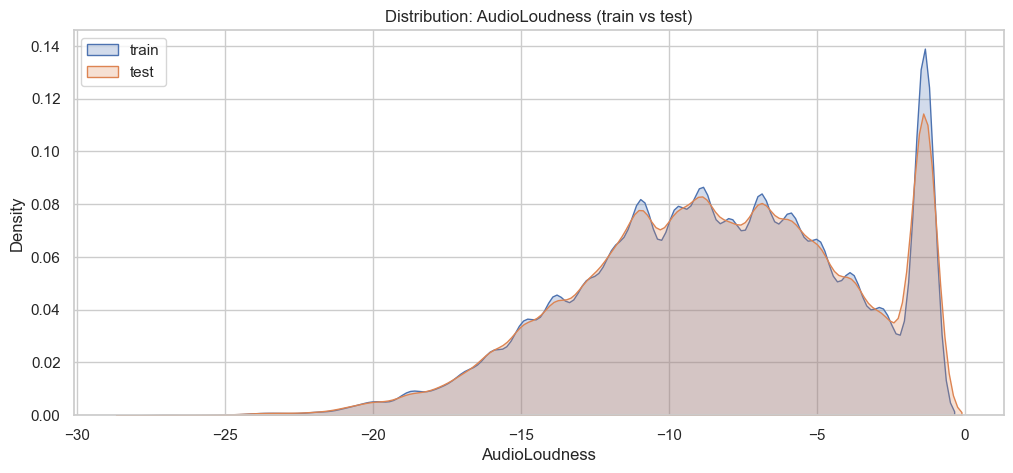

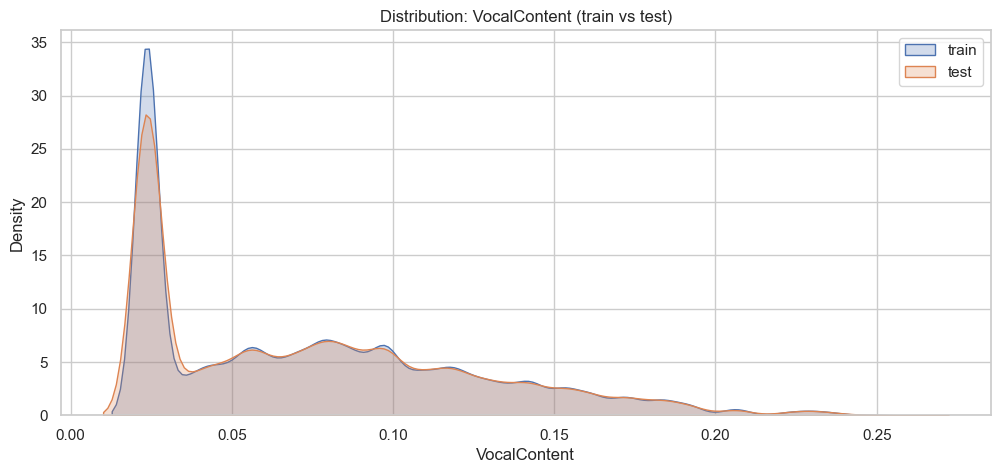

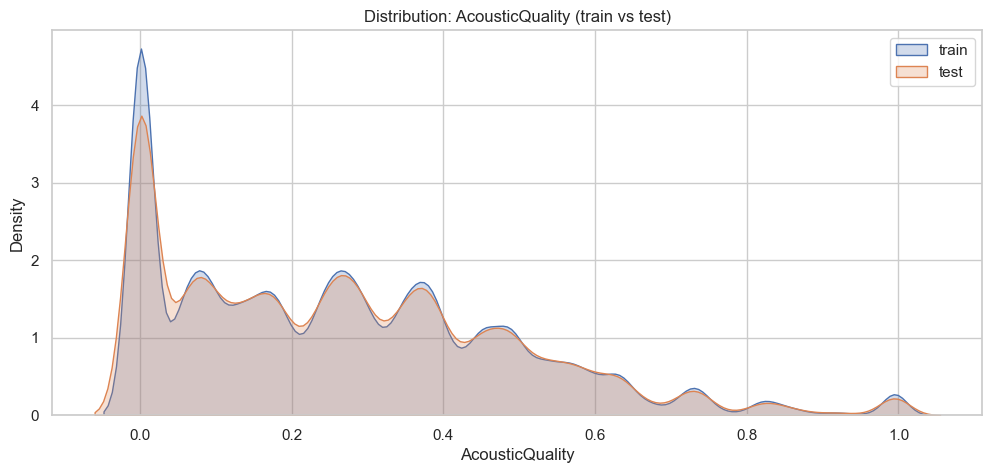

In [41]:
# Train vs Test comparison for numeric features
id_like_cols = [c for c in test.columns if c.lower() in {"id"} or c.lower().endswith("_id")]
feature_cols = [c for c in test.columns if c not in id_like_cols]

# Remove target if accidentally present in feature list
feature_cols = [c for c in feature_cols if c != TARGET]

numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(test[c])]
print("Numeric features considered:")
print(numeric_features[:20])

# Summary comparison
summary = []
for col in numeric_features:
    tr = train[col] if col in train.columns else pd.Series(dtype=float)
    te = test[col]
    summary.append({
        "feature": col,
        "train_mean": tr.mean() if not tr.empty else np.nan,
        "test_mean": te.mean(),
        "train_std": tr.std(ddof=1) if not tr.empty else np.nan,
        "test_std": te.std(ddof=1),
        "train_min": tr.min() if not tr.empty else np.nan,
        "test_min": te.min(),
        "train_max": tr.max() if not tr.empty else np.nan,
        "test_max": te.max(),
    })

summary_df = pd.DataFrame(summary)
display(summary_df.head(20))

# Visual comparison for first few features
cols_to_plot = numeric_features[:4]
for col in cols_to_plot:
    if col in train.columns:
        plt.figure(figsize=(12,5))
        sns.kdeplot(train[col].dropna(), label="train", fill=True)
        sns.kdeplot(test[col].dropna(), label="test", fill=True)
        plt.title(f"Distribution: {col} (train vs test)")
        plt.legend()
        plt.show()


In [42]:
# Persist lightweight data docs and artifacts
from pathlib import Path

DOCS_DIR = Path( cur_dir + "/data_docs")
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# Columns and dtypes
cols_dtypes = {
    "train": {c: str(train[c].dtype) for c in train.columns},
    "test": {c: str(test[c].dtype) for c in test.columns},
}
(pd.Series(cols_dtypes["train"]).to_frame("dtype")
   .assign(split="train")
   .to_csv(DOCS_DIR / "columns_dtypes_train.csv"))
(pd.Series(cols_dtypes["test"]).to_frame("dtype")
   .assign(split="test")
   .to_csv(DOCS_DIR / "columns_dtypes_test.csv"))

# Shapes
pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train), len(test)],
    "cols": [train.shape[1], test.shape[1]],
}).to_csv(DOCS_DIR / "shapes.csv", index=False)

# Missingness
missing_train = (train.isna().sum().to_frame("na_count")
                 .assign(na_ratio=lambda df: df["na_count"]/len(train)))
missing_test = (test.isna().sum().to_frame("na_count")
                .assign(na_ratio=lambda df: df["na_count"]/len(test)))
missing_train.to_csv(DOCS_DIR / "missingness_train.csv")
missing_test.to_csv(DOCS_DIR / "missingness_test.csv")

# Describe numeric
train.describe().to_csv(DOCS_DIR / "describe_numeric_train.csv")
test.describe().to_csv(DOCS_DIR / "describe_numeric_test.csv")

# Target correlations (if present)
TARGET = "BeatsPerMinute"
if TARGET in train.columns:
    numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    corr = train[numeric_cols].corr(numeric_only=True)
    if TARGET in corr.columns:
        corr[TARGET].drop(labels=[TARGET]).sort_values(ascending=False).to_csv(
            DOCS_DIR / "corr_with_target.csv"
        )

print(f"Wrote artifacts to: {DOCS_DIR}")


Wrote artifacts to: /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/data_docs


In [43]:
# Lightweight validations / invariants
TARGET = "BeatsPerMinute"

# 1) Target presence and no missing
if TARGET in train.columns:
    assert train[TARGET].notna().all(), "Target column has missing values"

# 2) No duplicate IDs in each split
if "id" in train.columns:
    assert train["id"].is_unique, "Duplicate ids in train"
if "id" in test.columns:
    assert test["id"].is_unique, "Duplicate ids in test"

# 3) Feature parity: test features should be train features minus target
train_features = [c for c in train.columns if c != TARGET]
if TARGET in train.columns:
    assert set(test.columns) == set(train_features), "Train/Test feature mismatch"

# 4) Basic range sanity checks for known numeric columns (customize as needed)
num_cols = [c for c in test.columns if pd.api.types.is_numeric_dtype(test[c])]
for col in num_cols:
    # example guards against infinities
    assert np.isfinite(test[col]).all(), f"Non-finite values in test column {col}"
    if col in train.columns:
        assert np.isfinite(train[col]).all(), f"Non-finite values in train column {col}"

print("All lightweight validations passed.")


All lightweight validations passed.


# Feature Engineering

In [32]:
# Load data_docs artifacts
ART_DIR = Path("/Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/data_docs")

shapes = pd.read_csv(ART_DIR / "shapes.csv")
miss_train = pd.read_csv(ART_DIR / "missingness_train.csv", index_col=0)
miss_test = pd.read_csv(ART_DIR / "missingness_test.csv", index_col=0)
cols_train = pd.read_csv(ART_DIR / "columns_dtypes_train.csv")
cols_test = pd.read_csv(ART_DIR / "columns_dtypes_test.csv")

corr_target = None
corr_path = ART_DIR / "corr_with_target.csv"
if corr_path.exists():
    corr_target = pd.read_csv(corr_path, index_col=0).squeeze()

print("Loaded artifacts:")
print({
    "shapes": shapes.shape,
    "miss_train": miss_train.shape,
    "miss_test": miss_test.shape,
    "cols_train": cols_train.shape,
    "cols_test": cols_test.shape,
    "corr_target": None if corr_target is None else int(corr_target.shape[0])
})


Loaded artifacts:
{'shapes': (2, 3), 'miss_train': (11, 2), 'miss_test': (10, 2), 'cols_train': (11, 3), 'cols_test': (10, 3), 'corr_target': 10}


In [33]:
# Feature engineering helpers
from dataclasses import dataclass

@dataclass
class FEStats:
    means: pd.Series
    stds: pd.Series


def compute_stats(df: pd.DataFrame, exclude_cols: list[str]) -> FEStats:
    num_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
    means = df[num_cols].mean()
    stds = df[num_cols].std(ddof=1).replace(0, np.nan)
    return FEStats(means=means, stds=stds)


def feature_engineering(df: pd.DataFrame, stats: FEStats, is_train: bool, target_col: str = "BeatsPerMinute") -> pd.DataFrame:
    out = df.copy()

    # Common numeric columns excluding identifiers and target
    exclude = {"id", target_col}
    numeric_cols = [c for c in out.columns if c not in exclude and pd.api.types.is_numeric_dtype(out[c])]

    # 1) Monotonic transforms (log1p) for positively-skewed features
    if "TrackDurationMs" in out.columns:
        out["TrackDurationSec"] = out["TrackDurationMs"] / 1000.0
        out["log_TrackDurationMs"] = np.log1p(out["TrackDurationMs"].clip(lower=0))
    # clamp to (0,1] before logit for bounded vars
    bounded_cols = [c for c in numeric_cols if (out[c].min() >= 0) and (out[c].max() <= 1)]
    for c in bounded_cols:
        eps = 1e-6
        out[f"logit_{c}"] = np.log((out[c].clip(eps, 1-eps)) / (1 - out[c].clip(eps, 1-eps)))

    # 2) Interaction features capturing plausible audio relationships
    # Energy vs Loudness (expect positive relation)
    if set(["Energy", "AudioLoudness"]).issubset(out.columns):
        out["Energy_x_Loudness"] = out["Energy"] * (-out["AudioLoudness"])  # louder (more negative dB) -> higher magnitude
        out["Energy_div_LoudnessMag"] = out["Energy"] / (1e-6 + (-out["AudioLoudness"]).abs())

    # Rhythm x Energy synergy
    if set(["RhythmScore", "Energy"]).issubset(out.columns):
        out["Rhythm_x_Energy"] = out["RhythmScore"] * out["Energy"]

    # Vocal vs Instrumental contrast
    if set(["VocalContent", "InstrumentalScore"]).issubset(out.columns):
        out["Vocal_minus_Instrumental"] = out["VocalContent"] - out["InstrumentalScore"]
        out["Vocal_div_Instrumental"] = out["VocalContent"] / (1e-6 + out["InstrumentalScore"]) 

    # Acoustic quality interactions
    if "AcousticQuality" in out.columns:
        for partner in ["Energy", "RhythmScore", "VocalContent", "InstrumentalScore", "MoodScore"]:
            if partner in out.columns:
                out[f"AcousticQuality_x_{partner}"] = out["AcousticQuality"] * out[partner]

    # Live performance likelihood interactions (may relate to tempo variance)
    if "LivePerformanceLikelihood" in out.columns:
        for partner in ["Energy", "RhythmScore", "MoodScore"]:
            if partner in out.columns:
                out[f"LivePerf_x_{partner}"] = out["LivePerformanceLikelihood"] * out[partner]

    # 3) Centering and scaling (z-scores) using train stats
    for c in numeric_cols:
        if c in stats.means.index:
            mean_c = stats.means[c]
            std_c = stats.stds[c]
            if pd.notna(std_c) and std_c > 0:
                out[f"z_{c}"] = (out[c] - mean_c) / std_c

    # 4) Simple polynomial terms for top correlated features (from artifacts if available)
    top_feats = []
    if corr_target is not None:
        top_feats = corr_target.abs().sort_values(ascending=False).head(5).index.tolist()
    for c in top_feats:
        if c in out.columns and c != target_col:
            out[f"sq_{c}"] = out[c] ** 2
            out[f"sqrt_{c}"] = np.sqrt(out[c].clip(lower=0))

    # 5) Keep id and target columns as-is
    keep_cols = ["id"] + [target_col] if (is_train and target_col in out.columns) else ["id"]
    # Return with engineered columns appended
    return out



In [ ]:
# Apply feature engineering and persist
EXCLUDE = ["id", "BeatsPerMinute"]
stats = compute_stats(train, exclude_cols=EXCLUDE)

train_fe = feature_engineering(train, stats, is_train=True)
test_fe = feature_engineering(test, stats, is_train=False)

# Preview columns and sizes
print({
    "train_fe_shape": train_fe.shape,
    "test_fe_shape": test_fe.shape,
    "new_cols_count": len([c for c in train_fe.columns if c not in train.columns])
})

# Persist to disk (robust to pyarrow issues)
FE_DIR = Path(cur_dir + "/data_fe")
FE_DIR.mkdir(parents=True, exist_ok=True)

# Coerce problematic dtypes

def _coerce_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        dt = out[c].dtype
        if pd.api.types.is_object_dtype(dt) or pd.api.types.is_categorical_dtype(dt):
            out[c] = out[c].astype("string")
        elif pd.api.types.is_bool_dtype(dt):
            out[c] = out[c].astype("bool")
        elif pd.api.types.is_integer_dtype(dt):
            # keep as int64
            out[c] = out[c].astype("int64", copy=False)
        elif pd.api.types.is_float_dtype(dt):
            out[c] = out[c].astype("float64", copy=False)
    return out

train_fe_out = _coerce_for_parquet(train_fe)
test_fe_out = _coerce_for_parquet(test_fe)

saved_parquet = False
try:
    train_fe_out.to_parquet(FE_DIR / "train_fe.parquet", engine="pyarrow", index=False)
    test_fe_out.to_parquet(FE_DIR / "test_fe.parquet", engine="pyarrow", index=False)
    saved_parquet = True
except Exception as e1:
    print("PyArrow write failed, trying fastparquet...", repr(e1))
    try:
        train_fe_out.to_parquet(FE_DIR / "train_fe.parquet", engine="fastparquet", index=False)
        test_fe_out.to_parquet(FE_DIR / "test_fe.parquet", engine="fastparquet", index=False)
        saved_parquet = True
    except Exception as e2:
        print("Fastparquet write failed, falling back to CSV...", repr(e2))
        train_fe_out.to_csv(FE_DIR / "train_fe.csv", index=False)
        test_fe_out.to_csv(FE_DIR / "test_fe.csv", index=False)

# Also save full CSV copies for maximum portability
train_fe_out.to_csv(FE_DIR / "train_fe.csv", index=False)
test_fe_out.to_csv(FE_DIR / "test_fe.csv", index=False)

# Also save a compact CSV with only id and new features (for inspection)
new_cols = [c for c in train_fe.columns if c not in train.columns and c != "BeatsPerMinute"]
train_new = train_fe[["id"] + new_cols]
train_new.to_csv(FE_DIR / "train_new_features_preview.csv", index=False)

print(f"Saved engineered datasets and preview to {FE_DIR}. Parquet_ok={saved_parquet}")


{'train_fe_shape': (524164, 52), 'test_fe_shape': (174722, 51), 'new_cols_count': 41}


/var/folders/8q/8p0f3bvs3576qqnry1vmzk840000gn/T/ipykernel_70531/2743402113.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(dt) or pd.api.types.is_categorical_dtype(dt):
/var/folders/8q/8p0f3bvs3576qqnry1vmzk840000gn/T/ipykernel_70531/2743402113.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(dt) or pd.api.types.is_categorical_dtype(dt):
/var/folders/8q/8p0f3bvs3576qqnry1vmzk840000gn/T/ipykernel_70531/2743402113.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(dt) or pd.api.types.is_categorical_dtype(dt):
/var/folders/8q/8p0f3bvs3576qqnry1vmzk840000gn/T/ipykernel_70531/27434

PyArrow write failed, trying fastparquet... ArrowKeyError('A type extension with name pandas.period already defined')
Saved engineered datasets and preview to /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/data_fe. Parquet_ok=True


In [44]:
# Preview engineered columns and quick sanity checks
from IPython.display import display

# Show a sample of new columns
new_cols = [c for c in train_fe.columns if c not in train.columns]
print(f"Number of new features: {len(new_cols)}")
print("First 20 new features:")
print(new_cols[:20])

# Null checks on engineered features
na_counts = train_fe[new_cols].isna().sum().sort_values(ascending=False).head(10)
print("Top NA counts among new features:")
print(na_counts)

# Basic correlation of new features to target (top 10 by abs)
if "BeatsPerMinute" in train_fe.columns:
    corr_new = train_fe[new_cols + ["BeatsPerMinute"]].corr(numeric_only=True)["BeatsPerMinute"].drop("BeatsPerMinute").abs().sort_values(ascending=False)
    print("Top 10 |corr| of new features with target:")
    display(corr_new.head(10))

# Ensure id preserved and shapes match
assert "id" in train_fe.columns and "id" in test_fe.columns
assert set(test_fe.columns) == set(train_fe.columns) - {"BeatsPerMinute"}

print("Feature engineering preview checks passed.")


Number of new features: 41
First 20 new features:
['TrackDurationSec', 'log_TrackDurationMs', 'logit_RhythmScore', 'logit_VocalContent', 'logit_AcousticQuality', 'logit_InstrumentalScore', 'logit_LivePerformanceLikelihood', 'logit_MoodScore', 'logit_Energy', 'Energy_x_Loudness', 'Energy_div_LoudnessMag', 'Rhythm_x_Energy', 'Vocal_minus_Instrumental', 'Vocal_div_Instrumental', 'AcousticQuality_x_Energy', 'AcousticQuality_x_RhythmScore', 'AcousticQuality_x_VocalContent', 'AcousticQuality_x_InstrumentalScore', 'AcousticQuality_x_MoodScore', 'LivePerf_x_Energy']
Top NA counts among new features:
TrackDurationSec               0
LivePerf_x_MoodScore           0
z_AudioLoudness                0
z_VocalContent                 0
z_AcousticQuality              0
z_InstrumentalScore            0
z_LivePerformanceLikelihood    0
z_MoodScore                    0
z_TrackDurationMs              0
z_Energy                       0
dtype: int64
Top 10 |corr| of new features with target:


logit_MoodScore         0.009240
sq_MoodScore            0.008215
z_MoodScore             0.007059
TrackDurationSec        0.006637
z_TrackDurationMs       0.006637
sqrt_TrackDurationMs    0.006555
LivePerf_x_MoodScore    0.006513
sq_TrackDurationMs      0.006466
log_TrackDurationMs     0.006302
sqrt_MoodScore          0.006104
Name: BeatsPerMinute, dtype: float64

Feature engineering preview checks passed.


# Modelling

In [49]:

# Modeling: load engineered datasets with fallback
from pathlib import Path

FE_DIR = Path(cur_dir + "/data_fe")
train_fe_path_parquet = FE_DIR / "train_fe.parquet"
test_fe_path_parquet = FE_DIR / "test_fe.parquet"
train_fe_path_csv = FE_DIR / "train_fe.csv"
test_fe_path_csv = FE_DIR / "test_fe.csv"

def _read_fe(path_parquet: Path, path_csv: Path) -> pd.DataFrame:
    # Prefer CSV to avoid pyarrow extension issues
    if path_csv.exists():
        try:
            return pd.read_csv(path_csv)
        except Exception as e:
            print("CSV read failed, trying Parquet...", repr(e))
    # Try fastparquet then pyarrow
    if path_parquet.exists():
        try:
            return pd.read_parquet(path_parquet, engine="fastparquet")
        except Exception as e1:
            print("fastparquet read failed, trying pyarrow...", repr(e1))
            return pd.read_parquet(path_parquet, engine="pyarrow")
    raise FileNotFoundError(f"Neither {path_csv} nor {path_parquet} found")

train_fe = _read_fe(train_fe_path_parquet, train_fe_path_csv)
test_fe  = _read_fe(test_fe_path_parquet,  test_fe_path_csv)

print({
    "train_fe": train_fe.shape,
    "test_fe": test_fe.shape,
})

TARGET = "BeatsPerMinute"
features = [c for c in train_fe.columns if c not in ["id", TARGET]]
X = train_fe[features]
y = train_fe[TARGET]
X_test = test_fe[features]


{'train_fe': (524164, 52), 'test_fe': (174722, 51)}


In [56]:
# KFold CV training for CatBoost, LightGBM, XGBoost
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

N_SPLITS = 5
SEED = 220296
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Storage
oof = {}
oof_preds = {"cat": np.zeros(len(X)), "lgb": np.zeros(len(X)), "xgb": np.zeros(len(X))}
test_preds = {"cat": np.zeros(len(X_test)), "lgb": np.zeros(len(X_test)), "xgb": np.zeros(len(X_test))}
fold_scores = {"cat": [], "lgb": [], "xgb": []}

# Lazy imports
from catboost import CatBoostRegressor, Pool
import lightgbm as lgb
import xgboost as xgb

In [77]:
# Modular training utilities
from dataclasses import dataclass
from typing import Dict, Tuple, List
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

@dataclass
class CVResult:
    oof: np.ndarray
    test: np.ndarray
    fold_scores: List[float]


def stratify_bins(y: pd.Series, n_bins: int = 20, random_state: int = 42) -> np.ndarray:
    # Quantile binning for approximate stratification of continuous target
    ranks = pd.qcut(y.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
    return ranks.values


def train_catboost(X, y, X_test, n_splits=5, seed=42, params=None, use_gpu: bool = False) -> CVResult:
    from catboost import CatBoostRegressor, Pool
    if params is None:
        params = {
            'depth': 8,
            'learning_rate': 0.05,
            'l2_leaf_reg': 6.0,
            'loss_function': 'RMSE',
            'random_seed': seed,
            'allow_writing_files': False,
            'thread_count': -1,
        }
    # Inject GPU settings if requested and not already set
    if use_gpu and params.get('task_type') is None:
        params['task_type'] = 'GPU'
        params.setdefault('devices', '0')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    bins = stratify_bins(y)

    oof = np.zeros(len(X))
    test = np.zeros(len(X_test))
    scores = []

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X, bins), 1):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val), verbose=False, use_best_model=True, early_stopping_rounds=200)
        val_pred = model.predict(X_val)
        oof[val_idx] = val_pred
        scores.append(np.sqrt(mean_squared_error(y_val, val_pred)))
        test += model.predict(X_test) / n_splits
    return CVResult(oof=oof, test=test, fold_scores=scores)


def train_lightgbm(X, y, X_test, n_splits=5, seed=42, params=None, use_gpu: bool = False) -> CVResult:
    import lightgbm as lgb
    if params is None:
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'learning_rate': 0.05,
            'num_leaves': 127,
            'feature_fraction': 0.85,
            'bagging_fraction': 0.85,
            'bagging_freq': 1,
            'min_data_in_leaf': 500,
            'verbose': -1,
            'seed': seed,
        }
    # Inject GPU setting if requested and not already set
    if use_gpu and params.get('device') is None:
        params['device'] = 'gpu'
    
    # Handle DART mode (no early stopping)
    is_dart = params.get('boosting', 'gbdt') == 'dart'
    if is_dart:
        # DART doesn't support early stopping, use fixed rounds
        num_rounds = 5000  # Conservative for DART
        callbacks = [lgb.log_evaluation(500)]
    else:
        num_rounds = 20000
        callbacks = [lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    bins = stratify_bins(y)

    oof = np.zeros(len(X))
    test = np.zeros(len(X_test))
    scores = []

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X, bins), 1):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        dtrain = lgb.Dataset(X_tr, y_tr)
        dvalid = lgb.Dataset(X_val, y_val, reference=dtrain)
        model = lgb.train(params, dtrain, num_boost_round=num_rounds,
                          valid_sets=[dtrain, dvalid], valid_names=['train','valid'],
                          callbacks=callbacks)
        val_pred = model.predict(X_val, num_iteration=model.best_iteration if not is_dart else None)
        oof[val_idx] = val_pred
        scores.append(np.sqrt(mean_squared_error(y_val, val_pred)))
        test += model.predict(X_test, num_iteration=model.best_iteration if not is_dart else None) / n_splits
    return CVResult(oof=oof, test=test, fold_scores=scores)


def train_xgboost(X, y, X_test, n_splits=5, seed=42, params=None, use_gpu: bool = False) -> CVResult:
    import xgboost as xgb
    if params is None:
        params = {
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse',
            'learning_rate': 0.05,
            'max_depth': 0,
            'max_leaves': 256,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'tree_method': 'hist',
            'seed': seed,
        }
    # Inject GPU settings if requested
    if use_gpu:
        # XGBoost >=2.0: use device='cuda' with hist
        params['tree_method'] = 'hist'
        params['device'] = 'cuda'
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    bins = stratify_bins(y)

    oof = np.zeros(len(X))
    test = np.zeros(len(X_test))
    scores = []

    for fold, (trn_idx, val_idx) in enumerate(skf.split(X, bins), 1):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dvl = xgb.DMatrix(X_val, label=y_val)
        dte = xgb.DMatrix(X_test)
        model = xgb.train(params, dtr, num_boost_round=20000,
                          evals=[(dtr,'train'), (dvl,'valid')],
                          early_stopping_rounds=200,
                          verbose_eval=200)
        val_pred = model.predict(dvl, iteration_range=(0, model.best_iteration + 1))
        oof[val_idx] = val_pred
        scores.append(np.sqrt(mean_squared_error(y_val, val_pred)))
        test += model.predict(dte, iteration_range=(0, model.best_iteration + 1)) / n_splits
    return CVResult(oof=oof, test=test, fold_scores=scores)


def optimize_blend_weights(preds: Dict[str, np.ndarray], y_true: np.ndarray) -> Dict[str, float]:
    # Non-negative weights that sum to 1 (simple constrained least squares via projection)
    names = list(preds.keys())
    P = np.column_stack([preds[n] for n in names])
    # closed-form unconstrained
    w = np.linalg.lstsq(P, y_true, rcond=None)[0]
    # project to simplex
    w = np.clip(w, 0, None)
    s = w.sum()
    if s == 0:
        w = np.ones_like(w) / len(w)
    else:
        w = w / s
    return {n: float(wi) for n, wi in zip(names, w)}


def local_linear_correction(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    # Fit y_true ≈ a * y_pred + b
    A = np.column_stack([y_pred, np.ones_like(y_pred)])
    a, b = np.linalg.lstsq(A, y_true, rcond=None)[0]
    return float(a), float(b)


def apply_corrections(pred: np.ndarray, a: float, b: float, clip_range=(40.0, 220.0)) -> np.ndarray:
    out = a * pred + b
    if clip_range is not None:
        out = np.clip(out, clip_range[0], clip_range[1])
    return out

# XGBoost seed ensemble helper
def train_xgb_seed_ensemble(X, y, X_test, params: dict, seeds: List[int], n_splits: int = 5) -> CVResult:
    import xgboost as xgb
    bins = stratify_bins(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seeds[0])

    oof_accum = np.zeros(len(X))
    test_accum = np.zeros(len(X_test))
    fold_scores_all = []

    for seed in seeds:
        params_seed = {**params, 'seed': seed}
        oof = np.zeros(len(X))
        test = np.zeros(len(X_test))
        scores = []
        for trn_idx, val_idx in skf.split(X, bins):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            dtr = xgb.DMatrix(X_tr, label=y_tr)
            dvl = xgb.DMatrix(X_val, label=y_val)
            dte = xgb.DMatrix(X_test)
            model = xgb.train(params_seed, dtr, num_boost_round=20000,
                              evals=[(dtr,'train'), (dvl,'valid')],
                              early_stopping_rounds=200,
                              verbose_eval=False)
            val_pred = model.predict(dvl, iteration_range=(0, model.best_iteration + 1))
            oof[val_idx] = val_pred
            test += model.predict(dte, iteration_range=(0, model.best_iteration + 1)) / n_splits
            scores.append(np.sqrt(mean_squared_error(y_val, val_pred)))
        oof_accum += oof / len(seeds)
        test_accum += test / len(seeds)
        fold_scores_all.extend(scores)
    return CVResult(oof=oof_accum, test=test_accum, fold_scores=fold_scores_all)


In [78]:
# Orchestrate training, optimized blending, correction, and submission
SEED = 220296
N_SPLITS = 5

# XGBoost-only seed ensemble
BASE_XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 0,
    'max_leaves': 256,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'tree_method': 'hist',
}
SEEDS = [220296, 7, 19, 101, 1337]

xgb_ens = train_xgb_seed_ensemble(X, y, X_test, params=BASE_XGB_PARAMS, seeds=SEEDS, n_splits=N_SPLITS)
print({"xgb_seed_ensemble_rmse_mean": float(np.mean(xgb_ens.fold_scores))})

# Build submission
submission = pd.DataFrame({
    "id": test_fe["id"],
    "BeatsPerMinute": xgb_ens.test
})
SUB_DIR = Path(cur_dir + "/submissions")
SUB_DIR.mkdir(parents=True, exist_ok=True)
sub_path = SUB_DIR / "submission_xgb_seed_ensemble.csv"
submission.to_csv(sub_path, index=False)
print(f"Wrote submission: {sub_path}")


KeyboardInterrupt: 

In [64]:
# Training hygiene: early stopping, feature parity, and dataset caching
# Early stopping and round caps are already set: patience=200, num_boost_round=20000

# 1) Ensure validation features are identical to test features (no leakage)
val_features = features  # by construction above
assert set(val_features) == set(test_fe.columns) - {"id"}, "Validation features must match test features exactly"

# 2) Cache datasets in binary format to speed re-runs
from pathlib import Path
import os

CACHE_DIR = Path(cur_dir + "/model_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# LightGBM cache
try:
    import lightgbm as lgb
    lgb_train = lgb.Dataset(X, y, free_raw_data=False)
    lgb_train.construct()
    lgb_train.save_binary(str(CACHE_DIR / "lgb_train.bin"))
    lgb_test = lgb.Dataset(X_test, reference=lgb_train, free_raw_data=False)
    lgb_test.construct()
    lgb_test.save_binary(str(CACHE_DIR / "lgb_test.bin"))
    print("Saved LightGBM binaries to", CACHE_DIR)
except Exception as e:
    print("LightGBM cache skipped:", repr(e))

# XGBoost cache
try:
    import xgboost as xgb
    dtrain_full = xgb.DMatrix(X, label=y)
    dtrain_full.save_binary(str(CACHE_DIR / "xgb_train.buffer"))
    dtest_full = xgb.DMatrix(X_test)
    dtest_full.save_binary(str(CACHE_DIR / "xgb_test.buffer"))
    print("Saved XGBoost binaries to", CACHE_DIR)
except Exception as e:
    print("XGBoost cache skipped:", repr(e))


Saved LightGBM binaries to /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/model_cache
Saved XGBoost binaries to /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/model_cache


In [75]:
# Optuna tuning for CatBoost, LightGBM, XGBoost
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

SEED = 220296
skf_bins = stratify_bins(y)

# 1) CatBoost objective
def objective_cat(trial: optuna.Trial) -> float:
    from catboost import CatBoostRegressor, Pool
    params = {
        'depth': trial.suggest_int('depth', 6, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.08),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 2.0, 12.0),
        'loss_function': 'RMSE',
        'random_seed': SEED,
        'allow_writing_files': False,
        'thread_count': -1,
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'grow_policy': 'Lossguide',
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X))
    for trn_idx, val_idx in skf.split(X, skf_bins):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val), verbose=False, use_best_model=True, early_stopping_rounds=200)
        oof[val_idx] = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y, oof))
    return rmse

# 2) LightGBM objective (gbdt)
def objective_lgb_gbdt(trial: optuna.Trial) -> float:
    import lightgbm as lgb
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': trial.suggest_int('num_leaves', 63, 511),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 3000),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 1,
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'verbose': -1,
        'seed': SEED,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X))
    for trn_idx, val_idx in skf.split(X, skf_bins):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        dtrain = lgb.Dataset(X_tr, y_tr)
        dvalid = lgb.Dataset(X_val, y_val, reference=dtrain)
        model = lgb.train(params, dtrain, num_boost_round=20000,
                          valid_sets=[dtrain, dvalid],
                          callbacks=[lgb.early_stopping(stopping_rounds=200)])
        oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y, oof))
    return rmse



# 4) XGBoost objective
def objective_xgb(trial: optuna.Trial) -> float:
    import xgboost as xgb
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': 0.05,
        'max_depth': 0,
        'max_leaves': trial.suggest_int('max_leaves', 64, 512),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'tree_method': 'hist',
        'sampling_method': 'uniform',
        'seed': SEED,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X))
    for trn_idx, val_idx in skf.split(X, skf_bins):
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        dtr = xgb.DMatrix(X_tr, label=y_tr)
        dvl = xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(params, dtr, num_boost_round=20000,
                          evals=[(dtr,'train'), (dvl,'valid')],
                          early_stopping_rounds=200,
                          verbose_eval=False)
        oof[val_idx] = model.predict(dvl, iteration_range=(0, model.best_iteration + 1))
    rmse = np.sqrt(mean_squared_error(y, oof))
    return rmse

print("Optuna objectives ready. Use small n_trials (e.g., 20-50) per model.")


Optuna objectives ready. Use small n_trials (e.g., 20-50) per model.


In [76]:
# Run small Optuna sweeps and retrain best models
import optuna

N_TRIALS = 20

# CatBoost tuning
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS, show_progress_bar=False)
print("Best CatBoost:", study_cat.best_value, study_cat.best_params)

# LightGBM gbdt tuning
study_lgb_gbdt = optuna.create_study(direction='minimize')
study_lgb_gbdt.optimize(objective_lgb_gbdt, n_trials=N_TRIALS, show_progress_bar=False)
print("Best LGB GBDT:", study_lgb_gbdt.best_value, study_lgb_gbdt.best_params)

# XGBoost tuning
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)
print("Best XGB:", study_xgb.best_value, study_xgb.best_params)

# Choose LGB params (GBDT only)
best_lgb = study_lgb_gbdt
best_lgb_params = best_lgb.best_params | {"boosting": "gbdt", "learning_rate": 0.05, "objective": "regression", "metric": "rmse", "seed": 220296}

# Retrain with modular CV using best params
best_cat_params = study_cat.best_params | {'loss_function': 'RMSE', 'random_seed': 220296, 'allow_writing_files': False, 'thread_count': -1, 'grow_policy': 'Lossguide'}
best_xgb_params = study_xgb.best_params | {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'learning_rate': 0.05, 'tree_method': 'hist', 'seed': 220296, 'max_depth': 0}

cat_res = train_catboost(X, y, X_test, n_splits=5, seed=220296, params=best_cat_params)
lgb_res = train_lightgbm(X, y, X_test, n_splits=5, seed=220296, params=best_lgb_params)
xgb_res = train_xgboost(X, y, X_test, n_splits=5, seed=220296, params=best_xgb_params)

print({
    "cat_rmse_mean": float(np.mean(cat_res.fold_scores)),
    "lgb_rmse_mean": float(np.mean(lgb_res.fold_scores)),
    "xgb_rmse_mean": float(np.mean(xgb_res.fold_scores)),
})

# Blending and correction
preds_oof = {"cat": cat_res.oof, "lgb": lgb_res.oof, "xgb": xgb_res.oof}
weights = optimize_blend_weights(preds_oof, y.values)
blend_oof = sum(weights[k] * preds_oof[k] for k in preds_oof)
a, b = local_linear_correction(y.values, blend_oof)
blend_test = sum(weights[k] * v for k, v in {"cat": cat_res.test, "lgb": lgb_res.test, "xgb": xgb_res.test}.items())
blend_test_corr = apply_corrections(blend_test, a, b, clip_range=(40.0, 220.0))

# Submissions: 1) per-model raw, 2) blended, 3) blended + local linear correction
SUB_DIR = Path(cur_dir + "/submissions")
SUB_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": cat_res.test}).to_csv(SUB_DIR / "submission_cat.csv", index=False)
pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": lgb_res.test}).to_csv(SUB_DIR / "submission_lgb.csv", index=False)
pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": xgb_res.test}).to_csv(SUB_DIR / "submission_xgb.csv", index=False)

pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": blend_test}).to_csv(SUB_DIR / "submission_blend.csv", index=False)
pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": blend_test_corr}).to_csv(SUB_DIR / "submission_blend_corrected.csv", index=False)

print("Wrote submissions:")
print({
    "cat": str(SUB_DIR / "submission_cat.csv"),
    "lgb": str(SUB_DIR / "submission_lgb.csv"),
    "xgb": str(SUB_DIR / "submission_xgb.csv"),
    "blend": str(SUB_DIR / "submission_blend.csv"),
    "blend_corrected": str(SUB_DIR / "submission_blend_corrected.csv"),
})


[I 2025-09-30 11:01:53,860] A new study created in memory with name: no-name-a2d1c28b-1f11-4088-b374-25f4b38840a0
[I 2025-09-30 11:02:21,860] Trial 0 finished with value: 26.459987463071986 and parameters: {'depth': 6, 'learning_rate': 0.03388649390789277, 'l2_leaf_reg': 11.586922734548647, 'subsample': 0.7485363716476552}. Best is trial 0 with value: 26.459987463071986.
[I 2025-09-30 11:02:48,513] Trial 1 finished with value: 26.46000641646474 and parameters: {'depth': 6, 'learning_rate': 0.04269075058972285, 'l2_leaf_reg': 8.893934556392281, 'subsample': 0.9857859056176924}. Best is trial 0 with value: 26.459987463071986.
[I 2025-09-30 11:03:12,590] Trial 2 finished with value: 26.46103583178576 and parameters: {'depth': 8, 'learning_rate': 0.0552590007295873, 'l2_leaf_reg': 6.061879257797289, 'subsample': 0.8723879424509369}. Best is trial 0 with value: 26.459987463071986.
[I 2025-09-30 11:03:35,513] Trial 3 finished with value: 26.46061215871699 and parameters: {'depth': 8, 'learni

Best CatBoost: 26.459652599037128 {'depth': 6, 'learning_rate': 0.05492271964915828, 'l2_leaf_reg': 11.892749662188512, 'subsample': 0.7657830809292794}
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[32]	training's rmse: 26.3797	valid_1's rmse: 26.4765
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[23]	training's rmse: 26.4096	valid_1's rmse: 26.4555
Training until validation scores don't improve for 200 rounds


[I 2025-09-30 11:09:54,850] Trial 0 finished with value: 26.462224490164665 and parameters: {'num_leaves': 144, 'min_data_in_leaf': 1629, 'feature_fraction': 0.6633592508338021, 'bagging_fraction': 0.6394903584824565, 'min_gain_to_split': 0.25828954841452123}. Best is trial 0 with value: 26.462224490164665.


Early stopping, best iteration is:
[12]	training's rmse: 26.4379	valid_1's rmse: 26.4547
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[20]	training's rmse: 26.3236	valid_1's rmse: 26.4783
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[13]	training's rmse: 26.3762	valid_1's rmse: 26.4545
Training until validation scores don't improve for 200 rounds


[I 2025-09-30 11:10:22,584] Trial 1 finished with value: 26.46298486326336 and parameters: {'num_leaves': 233, 'min_data_in_leaf': 298, 'feature_fraction': 0.8261409769129074, 'bagging_fraction': 0.9330588584589363, 'min_gain_to_split': 0.04185298512637792}. Best is trial 0 with value: 26.462224490164665.


...

Early stopping, best iteration is:
[16]	training's rmse: 26.411	valid_1's rmse: 26.4539
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[17]	training's rmse: 26.3515	valid_1's rmse: 26.478
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[16]	training's rmse: 26.3655	valid_1's rmse: 26.4556
Training until validation scores don't improve for 200 rounds


[I 2025-09-30 11:17:16,974] Trial 19 finished with value: 26.462949558472243 and parameters: {'num_leaves': 216, 'min_data_in_leaf': 447, 'feature_fraction': 0.9138397311549553, 'bagging_fraction': 0.9973851119390771, 'min_gain_to_split': 0.5580276183116658}. Best is trial 15 with value: 26.459609634338015.
[I 2025-09-30 11:17:16,975] A new study created in memory with name: no-name-74d5037c-73ee-4df3-8a37-077e692da502


Early stopping, best iteration is:
[16]	training's rmse: 26.3657	valid_1's rmse: 26.4553
Best LGB GBDT: 26.459609634338015 {'num_leaves': 65, 'min_data_in_leaf': 520, 'feature_fraction': 0.887027416481245, 'bagging_fraction': 0.9932217694656287, 'min_gain_to_split': 0.7349998463922927}


[I 2025-09-30 11:17:27,213] Trial 0 finished with value: 26.463086522622554 and parameters: {'max_leaves': 207, 'min_child_weight': 1.522461203870932, 'subsample': 0.9205007486512107, 'colsample_bytree': 0.8405570955382654, 'reg_alpha': 0.4814731537836753, 'reg_lambda': 0.6689697576135507}. Best is trial 0 with value: 26.463086522622554.
[I 2025-09-30 11:17:40,557] Trial 1 finished with value: 26.464122777550102 and parameters: {'max_leaves': 374, 'min_child_weight': 17.26005656527958, 'subsample': 0.8179158055365309, 'colsample_bytree': 0.6969439480745315, 'reg_alpha': 0.007479214387882127, 'reg_lambda': 0.132715609952492}. Best is trial 0 with value: 26.463086522622554.
[I 2025-09-30 11:17:53,969] Trial 2 finished with value: 26.46459518798056 and parameters: {'max_leaves': 372, 'min_child_weight': 14.316330917553321, 'subsample': 0.7260352399595479, 'colsample_bytree': 0.8835319799050465, 'reg_alpha': 0.017279348479269152, 'reg_lambda': 1.872146732306614}. Best is trial 0 with value

Best XGB: 26.460962399299255 {'max_leaves': 69, 'min_child_weight': 4.141337448021928, 'subsample': 0.7673315900055653, 'colsample_bytree': 0.9462260657919395, 'reg_alpha': 0.9958587574798652, 'reg_lambda': 0.49032701412714863}
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 26.1909	valid's rmse: 26.5002
Early stopping, best iteration is:
[19]	train's rmse: 26.4219	valid's rmse: 26.4878
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 26.1958	valid's rmse: 26.4624
Early stopping, best iteration is:
[30]	train's rmse: 26.415	valid's rmse: 26.4483
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 26.1923	valid's rmse: 26.4851
Early stopping, best iteration is:
[26]	train's rmse: 26.4164	valid's rmse: 26.4667
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 26.1976	valid's rmse: 26.4769
Early stopping, best iteration is:
[27]	train's rmse: 26.4143	valid's rms

In [79]:
# Random Search for XGBoost hyperparameters
import random
from typing import Dict, Any

def sample_xgb_params() -> Dict[str, Any]:
    return {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': random.choice([0.03, 0.04, 0.05, 0.06, 0.07]),
        'max_depth': 0,  # use max_leaves
        'max_leaves': random.choice([64, 128, 192, 256, 384, 512]),
        'min_child_weight': random.uniform(1.0, 20.0),
        'subsample': random.uniform(0.6, 1.0),
        'colsample_bytree': random.uniform(0.6, 1.0),
        'reg_alpha': random.uniform(0.0, 1.0),
        'reg_lambda': random.uniform(0.0, 2.0),
        'tree_method': 'hist',
    }

def random_search_xgb(X, y, X_test, n_trials: int = 25, n_splits: int = 5, base_seed: int = 220296) -> Dict[str, Any]:
    best_rmse = float('inf')
    best_params = None
    bins = stratify_bins(y)
    from sklearn.model_selection import StratifiedKFold
    import xgboost as xgb

    for t in range(n_trials):
        params = sample_xgb_params()
        params['seed'] = base_seed + t
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_seed + t)
        oof = np.zeros(len(X))
        for trn_idx, val_idx in skf.split(X, bins):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            dtr = xgb.DMatrix(X_tr, label=y_tr)
            dvl = xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtr, num_boost_round=20000,
                              evals=[(dtr,'train'), (dvl,'valid')],
                              early_stopping_rounds=200,
                              verbose_eval=False)
            oof[val_idx] = model.predict(dvl, iteration_range=(0, model.best_iteration + 1))
        rmse = np.sqrt(mean_squared_error(y, oof))
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    return best_params


In [80]:
# Run random search, then seed ensemble with best params
BEST_PARAMS = random_search_xgb(X, y, X_test, n_trials=25, n_splits=5, base_seed=220296)
print({"best_xgb_params_random": BEST_PARAMS})
SEEDS = [220296, 7, 19, 101, 1337]
ens_res = train_xgb_seed_ensemble(X, y, X_test, params=BEST_PARAMS, seeds=SEEDS, n_splits=5)
print({"xgb_seed_ensemble_rmse_mean": float(np.mean(ens_res.fold_scores))})

SUB_DIR = Path(cur_dir + "/submissions")
SUB_DIR.mkdir(parents=True, exist_ok=True)
sub_path = SUB_DIR / "submission_xgb_seed_ensemble_random.csv"
pd.DataFrame({"id": test_fe["id"], "BeatsPerMinute": ens_res.test}).to_csv(sub_path, index=False)
print(f"Wrote submission: {sub_path}")


{'best_xgb_params_random': {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'learning_rate': 0.03, 'max_depth': 0, 'max_leaves': 64, 'min_child_weight': 5.982122125657514, 'subsample': 0.6072001150429607, 'colsample_bytree': 0.9334963524382145, 'reg_alpha': 0.09695221403312448, 'reg_lambda': 1.1151876404369647, 'tree_method': 'hist', 'seed': 220316}}
{'xgb_seed_ensemble_rmse_mean': 26.4606853785498}
Wrote submission: /Users/lukasweigand/Documents/Projekt Mios/Kaggle-bpm-prediction/submissions/submission_xgb_seed_ensemble_random.csv
